# Импорты

In [1]:
from unittest.mock import patch

import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import json

from astropy.extern.configobj.validate import is_list
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from scipy.optimize import minimize

from tqdm.auto import tqdm

/beta/home/larin/.virtualenvs/FlashlightColor/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Загрузка датасетов

In [2]:
krinov = pd.read_csv("data/krinov.csv")
krinov.set_index('wavelength', inplace=True)
krinov = krinov.loc[range(400, 710, 10)]
krinov.head()

,0,1,2,3,4,5,6,7,8,9,...,345,346,347,348,349,350,351,352,353,354
wavelength,,,,,,,,,,,,,,,,,,,,,
400.0,0.051000,0.058000,0.047000,0.026000,0.059000,0.072000,0.044000,0.033000,0.084000,0.020000,...,0.192000,0.053000,0.165000,0.115000,0.210000,0.062000,0.14200,0.151000,0.20400,0.075000
410.0,0.052444,0.057550,0.048427,0.027315,0.060532,0.073665,0.045428,0.034375,0.086664,0.020176,...,0.187135,0.053544,0.168510,0.121950,0.212915,0.063528,0.15014,0.153390,0.22562,0.081612
420.0,0.054000,0.056000,0.049000,0.030000,0.061000,0.074000,0.047000,0.037000,0.086000,0.020000,...,0.188000,0.055000,0.170000,0.125000,0.212000,0.063000,0.15300,0.154000,0.24000,0.086000
430.0,0.060783,0.054049,0.050047,0.031101,0.061948,0.074062,0.048992,0.039142,0.091069,0.020997,...,0.192185,0.057998,0.176025,0.130105,0.215165,0.064061,0.15894,0.158995,0.25295,0.092080
440.0,0.062000,0.052000,0.052000,0.034000,0.061000,0.074000,0.050000,0.044000,0.097000,0.022000,...,0.197000,0.060000,0.181000,0.136000,0.220000,0.066000,0.16100,0.162000,0.25900,0.099000


In [3]:
munsell = pd.read_csv("data/munsell.csv")
munsell.set_index('wavelength', inplace=True)
munsell = munsell.loc[range(400, 710, 10)]
munsell.head()

,0,1,2,3,4,5,6,7,8,9,...,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268
wavelength,,,,,,,,,,,,,,,,,,,,,
400.0,0.42400,0.3967,0.33770,0.26110,0.18220,0.11590,0.06860,0.05210,0.3889,0.33320,...,0.0628,0.30970,0.24330,0.16570,0.1051,0.2284,0.16310,0.11590,0.1708,0.10470
410.0,0.63445,0.5154,0.38970,0.27695,0.18600,0.11465,0.06905,0.04775,0.4986,0.37795,...,0.0613,0.35155,0.25745,0.16445,0.1048,0.2442,0.16135,0.11100,0.1666,0.10215
420.0,0.69580,0.5326,0.38770,0.27000,0.17960,0.11140,0.06600,0.04620,0.5074,0.37420,...,0.0614,0.34380,0.24560,0.15800,0.1001,0.2337,0.15610,0.10410,0.1590,0.09910
430.0,0.69880,0.5229,0.38045,0.26185,0.17405,0.10775,0.06470,0.04695,0.4944,0.36195,...,0.0592,0.33440,0.23545,0.15390,0.0981,0.2251,0.15000,0.10095,0.1545,0.09700
440.0,0.69800,0.5212,0.37520,0.26000,0.17200,0.11080,0.06290,0.04960,0.4879,0.35430,...,0.0579,0.32730,0.23010,0.15240,0.0977,0.2205,0.14800,0.09450,0.1548,0.09600


In [4]:
munsell['0'].T

wavelength
400.0    0.42400
410.0    0.63445
420.0    0.69580
430.0    0.69880
440.0    0.69800
450.0    0.69380
460.0    0.69580
470.0    0.69745
480.0    0.69180
490.0    0.67185
500.0    0.66720
510.0    0.67120
520.0    0.66040
530.0    0.64895
540.0    0.65650
550.0    0.69410
560.0    0.73280
570.0    0.75625
580.0    0.76650
590.0    0.76945
600.0    0.76690
610.0    0.76490
620.0    0.76280
630.0    0.76445
640.0    0.76490
650.0    0.76135
660.0    0.75970
670.0    0.76005
680.0    0.75760
690.0    0.75770
700.0    0.75850
Name: 0, dtype: float64

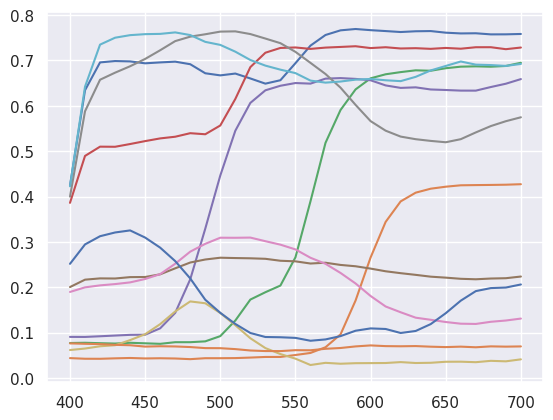

In [5]:
sns.set_theme("notebook")
for i in range(0, 1200, 100):
    plt.plot(munsell.index, munsell[str(i)])
plt.show()

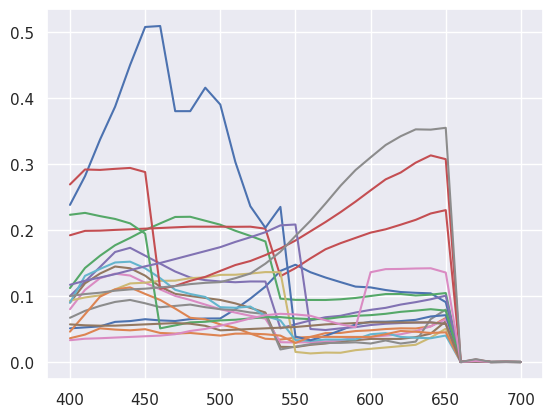

In [6]:
sns.set_theme("notebook")
for i in range(0, 350, 20):
    plt.plot(krinov.index, krinov[str(i)])
plt.show()

In [7]:
# TODO решить проблемы с colour-science и нормально доставать спектры
# 400-700 нм
light = {
    'D65': np.array([82.75, 91.49, 93.43, 86.68, 104.86, 117.01, 117.81, 114.86, 115.84, 108.81,
                     109.35, 107.80, 104.79, 107.69, 104.41, 104.05, 100.00, 96.33, 95.79, 88.77,
                     90.01, 89.60, 87.70, 83.29, 83.70, 80.03, 80.21, 82.28, 78.28, 69.71,
                     71.61]),

    'A': np.array([14.71, 20.85, 28.66, 38.31, 49.98, 63.72, 79.54, 97.40, 117.31, 139.05,
                    162.53, 187.53, 213.84, 241.14, 269.15, 297.55, 326.04, 354.33, 382.17, 409.30,
                    435.48, 460.50, 484.20, 506.41, 527.01, 545.92, 563.02, 578.26, 591.56, 602.88,
                    612.21])
}

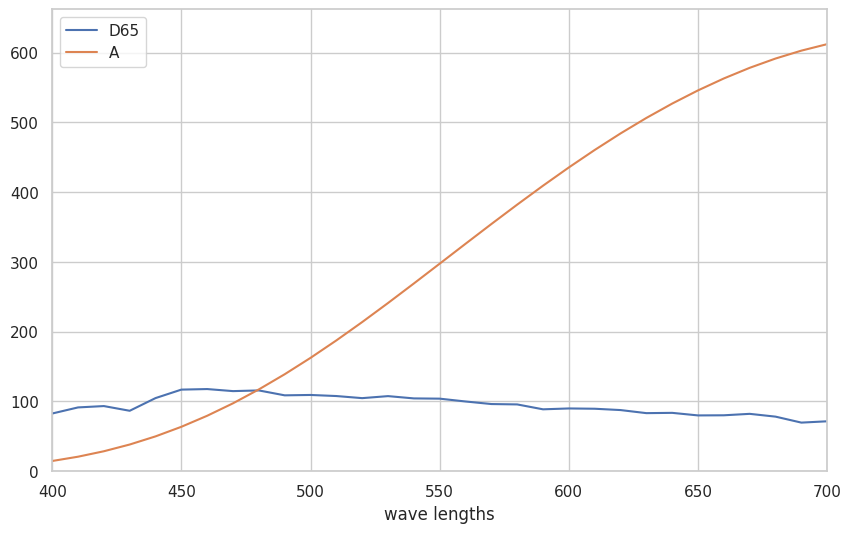

In [8]:
wavelengths = np.arange(400, 710, 10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(wavelengths, light['D65'], label='D65')
plt.plot(wavelengths, light['A'], label='A')

plt.legend(frameon=True)

plt.xlim(400, 700)
plt.xlabel('wave lengths')
plt.ylim(0, max(light['A']) + 50)

plt.show()

In [9]:
# Canon_EOS_100D from https://zenodo.org/records/6590768
data = json.load(open('data/Canon_100D.json'))

main_data = data['spectral_data']['data']['main']

sensor = pd.DataFrame.from_dict(main_data, orient='index', columns=['R', 'G', 'B'])

sensor.index = sensor.index.astype(int)
sensor = sensor.sort_index()

sensor.index.name = 'wavelength'

sensor

,R,G,B
wavelength,,,
380,0.000998,0.001305,0.001135
385,0.001027,0.001231,0.001623
390,0.001056,0.001156,0.002111
395,0.001086,0.001081,0.002599
400,0.001754,0.002087,0.011398
...,...,...,...
760,0.000252,0.000258,0.000092
765,0.000252,0.000258,0.000092
770,0.000252,0.000258,0.000092


In [10]:
sensor = sensor.loc[range(400, 710, 10)]
sensor

,R,G,B
wavelength,,,
400,0.001754,0.002087,0.011398
410,0.009403,0.017750,0.156735
420,0.019300,0.057689,0.563169
430,0.009038,0.063778,0.671568
440,0.004712,0.086512,0.746173
450,0.003807,0.103967,0.818211
460,0.005492,0.136323,0.821063
470,0.012958,0.322304,0.814278
480,0.023547,0.542565,0.755624


In [11]:
light['D65'].size

31

In [12]:
sensor

,R,G,B
wavelength,,,
400,0.001754,0.002087,0.011398
410,0.009403,0.017750,0.156735
420,0.019300,0.057689,0.563169
430,0.009038,0.063778,0.671568
440,0.004712,0.086512,0.746173
450,0.003807,0.103967,0.818211
460,0.005492,0.136323,0.821063
470,0.012958,0.322304,0.814278
480,0.023547,0.542565,0.755624


# Частный пример

In [13]:
response = sensor.multiply(light['D65'] * krinov['100'], axis=0).sum(axis=0)

In [14]:
response.values

array([19.61399748, 71.2169003 , 91.2966317 ])

In [15]:
patch = np.broadcast_to(response, (24, 24, 3))
patch

array([[[19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        ...,
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ]],

       [[19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        ...,
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ]],

       [[19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        ...,
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ],
        [19.61399748, 71.2169003 , 91.2966317 ]],

       ...,

       [[19.61399748, 71.2169003 , 91.2966317 ],
        [19

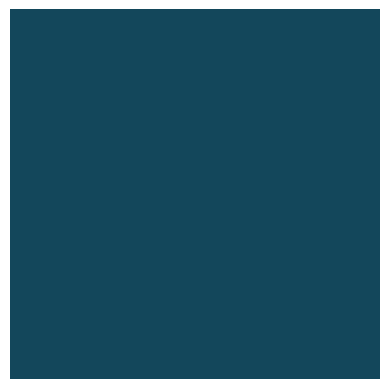

In [16]:
sns.set_theme(style="white")
img_to_show = patch.astype(np.uint8)

img_final = np.clip(img_to_show, 0, 255).astype(np.uint8)
plt.axis('off')
plt.imshow(img_final)
plt.show()

# А теперь делаем сетку патчей как в статье

In [17]:
krinov.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '345', '346', '347', '348', '349', '350', '351', '352', '353', '354'],
      dtype='object', length=355)

In [18]:
# (K, N) @ (N, 3) = (K, 3)
selected_surfaces = munsell[[str(i) for i in range(0, 1250, 50)]]
rgb_all = selected_surfaces.T @ (sensor.values * light['D65'][:, np.newaxis])
rgb_all

,0,1,2
0,395.132611,791.811449,581.624181
50,76.892118,106.840069,73.240818
100,122.488215,82.547948,40.943873
150,112.634810,163.443642,95.848007
200,293.468651,298.692466,90.584763
250,234.200324,353.450972,157.593115
300,379.976078,753.735503,467.146214
350,197.986917,352.219781,139.024700
400,334.510480,609.462330,204.258371
450,349.942549,750.342959,406.022451


In [19]:
rgb_normalized = rgb_all / rgb_all.max()
rgb_8bit = (rgb_normalized * 255).astype(np.uint8)
rgb_8bit.shape

(25, 3)

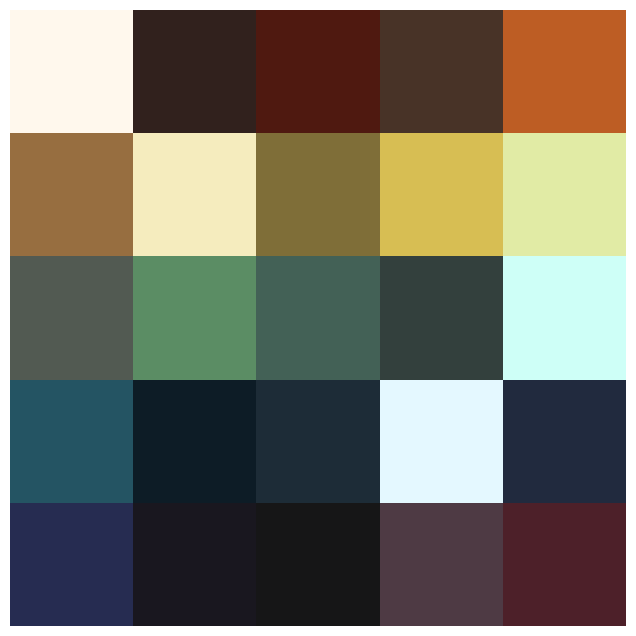

In [20]:
cells = rgb_8bit.values[:, np.newaxis, np.newaxis, :]

cells_expanded = np.tile(cells, (1, 10, 10, 1))

grid_shape = (5, 5)
grid = cells_expanded.reshape(grid_shape + (10, 10, 3))

final_image = grid.transpose(0, 2, 1, 3, 4).reshape(grid_shape[0]*10, grid_shape[1]*10, 3)

plt.figure(figsize=(10, 8))
plt.imshow(final_image)
plt.axis('off')
plt.show()

# Восстановление D65 по данным rgb из A


In [21]:
D_65_rgb = munsell.T @ (sensor.values * light['D65'][:, np.newaxis])
A_rgb = munsell.T @ (sensor.values * light['A'][:, np.newaxis])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    D_65_rgb, A_rgb,
    test_size=0.2,
    random_state=179,
    shuffle=True
)

In [23]:
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

M_sklearn = model.coef_.T
M_sklearn

array([[ 5.67745669,  1.24555341,  0.01676433],
       [-0.64391761,  2.35174476,  0.3335057 ],
       [ 0.21063536, -0.60617616,  0.61870722]])

# Поиск самого гладкого решения

In [24]:
def get_gradient_matrix(n=31):
    nabla = np.zeros((n, n))

    # матрица полностью из статьи
    for i in range(1, n-1):
        nabla[i, i] = -1
        nabla[i, i+1] = 1

    val_edge = 1 / np.sqrt(2)
    nabla[0, 0] = -val_edge
    nabla[0, 1] = val_edge

    nabla[-1, -2] = -val_edge
    nabla[-1, -1] = val_edge

    return nabla

nabla = get_gradient_matrix(31)
Q = nabla.T @ nabla

In [25]:
def estimate_reflectance(rgb_target, sensor_matrix, light_spectrum):
    """
    rgb_target: [R, G, B] - сигнал с камеры
    sensor_matrix: (N, 3) - чувствительность каналов
    light_spectrum: (N,) - спектр источника (например, D65)
    """
    n = len(light_spectrum)

    A = (sensor_matrix.values * light_spectrum[:, np.newaxis]).T

    nabla = get_gradient_matrix(n)
    Q = nabla.T @ nabla
    def objective(s):
        return s.T @ Q @ s

    constraints = [{'type': 'eq', 'fun': lambda s: A @ s - rgb_target}]

    bounds = [(0, 1) for _ in range(n)]

    s0 = np.full(n, 0.5)

    res = minimize(objective, s0, method='SLSQP', bounds=bounds, constraints=constraints)

    return res.x

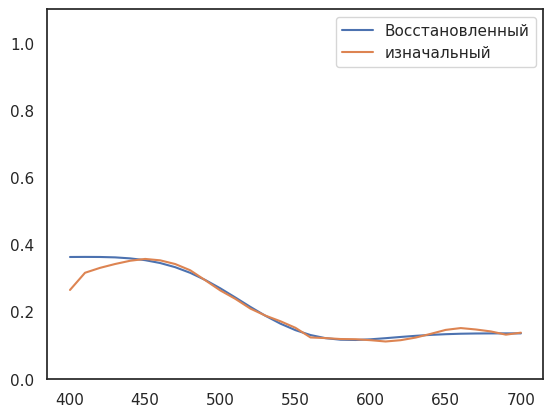

In [26]:
recovered_s = estimate_reflectance(y_train.iloc[0], sensor, light['A'])

import matplotlib.pyplot as plt
wavelengths = np.arange(400, 710, 10)
plt.plot(wavelengths, recovered_s, label='Восстановленный')
plt.plot(wavelengths, munsell['923'], label = "изначальный")
plt.ylim(0, 1.1)
plt.legend()
plt.show()

In [27]:
num_samples = 12
test_indices = range(num_samples)

recovered_list = []
original_list = []

for i in test_indices:
    rec_s = estimate_reflectance(X_test.iloc[i], sensor, light['D65'])
    recovered_list.append(rec_s)

    orig_idx = X_test.index[i]
    original_list.append(munsell[orig_idx])

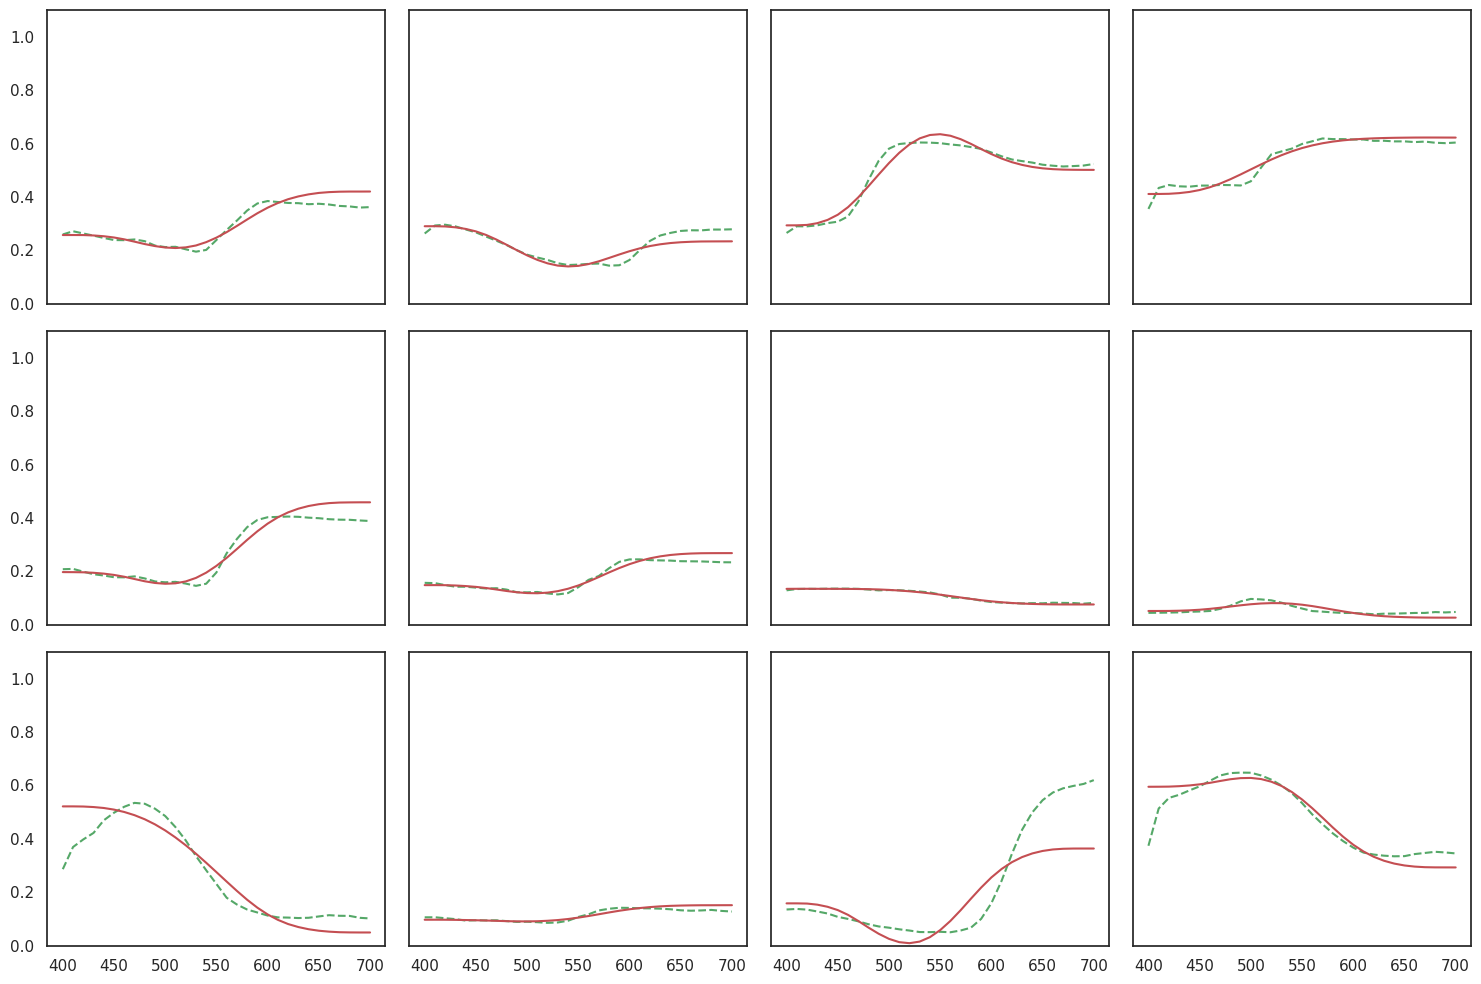

In [28]:
rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

wavelengths = np.arange(400, 710, 10)

for i in range(num_samples):
    ax = axes[i]
    ax.plot(wavelengths, original_list[i], 'g--', label='Изначальный')
    ax.plot(wavelengths, recovered_list[i], 'r', label='Восстановленный')

    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Пока глупые выводы
- Можно заметить, что спектры хорошо восстановились
- При этом при больших перепадах на концах видно как из-за ограничения на гладкость у нас не получается их повторить

# Цели
- Добавить метрики
- Сравнить при преобразовании матрицей
- Сравнить при несокльких источниках когда ограничений на функцию будет 3 и больше
- Подумать что делать с концами

In [29]:
illium = pd.read_csv("data/illum.csv")
illium.head()

,wavelength,A18,A24,A28,D50,D55,D65,D75,D95,F1,...,L-9,L-10,L-11,L-12,L-13,L-14,L-15,L-LIFX-R,L-LIFX-G,L-LIFX-B
0,300,7.644910e-07,0.000019,0.000086,0.000015,0.000014,0.000021,0.000027,9.401700e-19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,301,8.214660e-07,0.000020,0.000090,0.000023,0.000033,0.000033,0.000035,4.706710e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,302,8.822190e-07,0.000021,0.000093,0.000032,0.000053,0.000047,0.000045,9.149980e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,303,9.469680e-07,0.000022,0.000097,0.000045,0.000074,0.000065,0.000060,1.298860e-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,304,1.015940e-06,0.000023,0.000101,0.000062,0.000095,0.000088,0.000081,1.622290e-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
illium.set_index('wavelength', inplace=True)
illium = illium.loc[400:700:10]

In [31]:
illium = illium / illium.sum(axis=0)

In [32]:
D_65_rgb = munsell.T @ (sensor.values * illium['D65'].values[:, np.newaxis])

munsell_train, munsell_test, D_65_rgb_train, D_65_rgb_test = train_test_split(
    munsell.T, D_65_rgb,
    test_size=0.2,
    random_state=179,
    shuffle=True
)

In [33]:
models = dict()
for light in illium.columns:
    model = LinearRegression(fit_intercept=False)
    x_train = munsell_train @ (sensor.values * illium[light].values[:, np.newaxis])
    model.fit(x_train, D_65_rgb_train)
    models[light] = model

In [34]:
num_samples = 12
test_indices = range(num_samples)

recovered_list = []
recovered_list_from_D65 = []
original_list = []

for i in tqdm(test_indices, desc="Processing samples"):
    rec_s_list = []
    rec_from_D65_list = []
    for light in illium.columns:
        rgb = (munsell_test @ (sensor.values * illium[light].values[:, np.newaxis])).iloc[i]
        rec_s = estimate_reflectance(rgb, sensor, illium[light].values)
        rec_from_D65 = estimate_reflectance(models[light].predict(rgb.values.reshape(1, -1))[0], sensor, illium['D65'].values)
        rec_s_list.append(rec_s)
        rec_from_D65_list.append(rec_from_D65)

    recovered_list.append(rec_s_list)
    recovered_list_from_D65.append(rec_from_D65_list)
    original_list.append(munsell_test.iloc[i])

Processing samples: 100%|██████████| 12/12 [01:04<00:00,  5.36s/it]


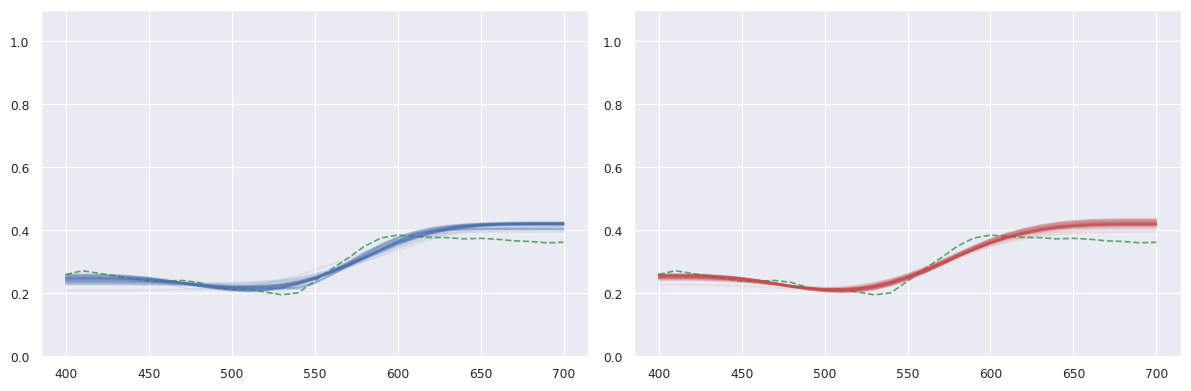

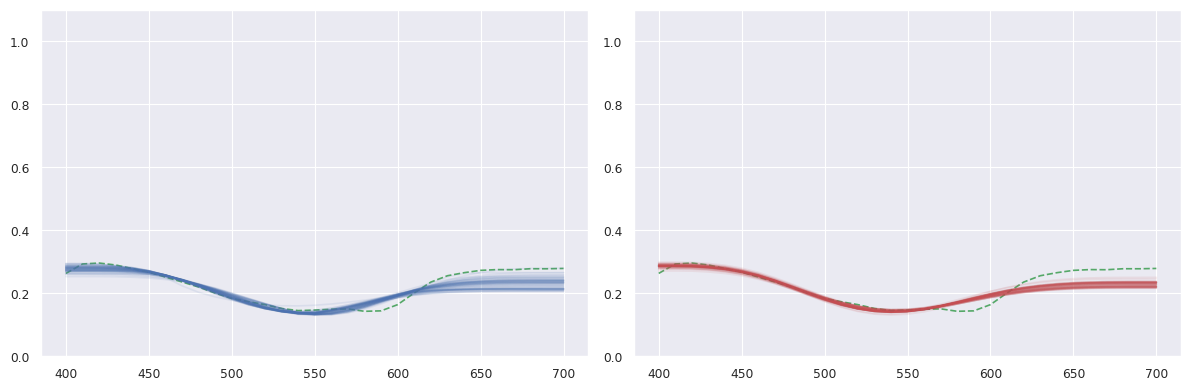

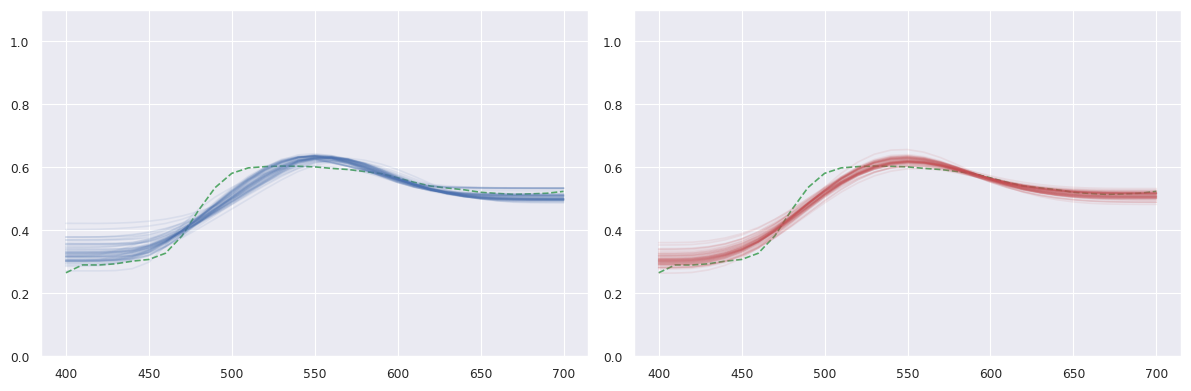

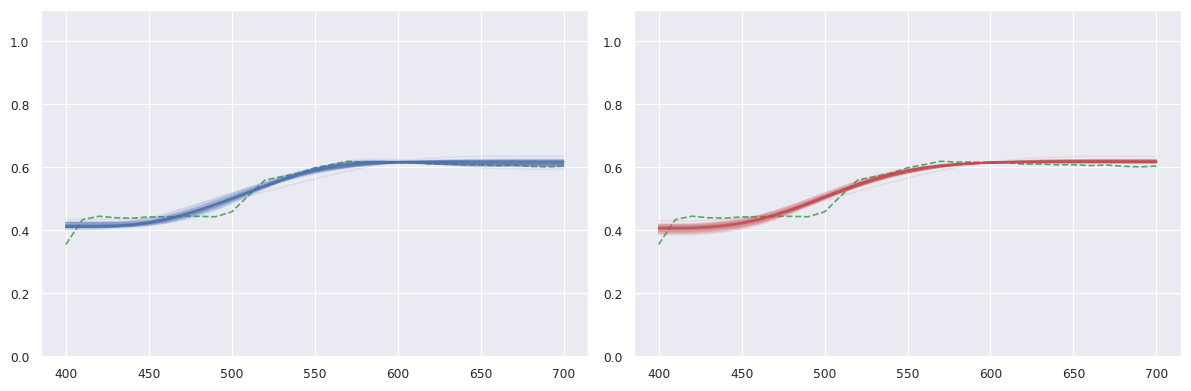

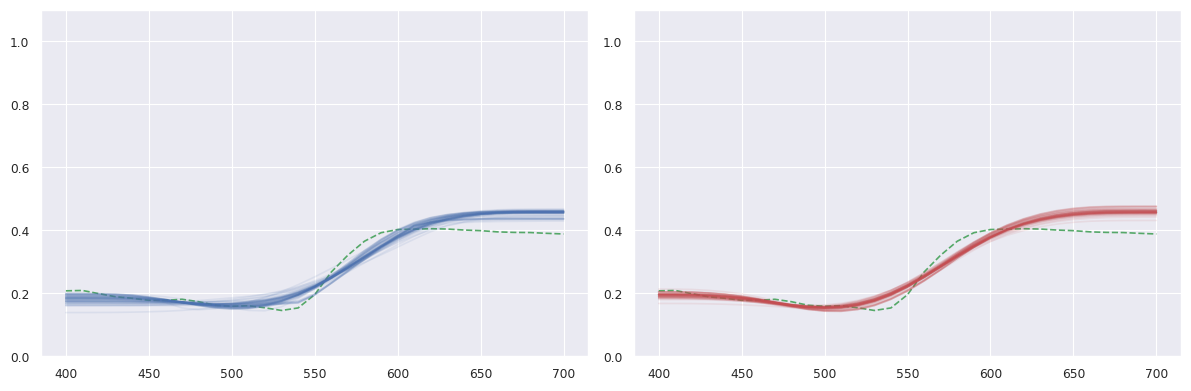

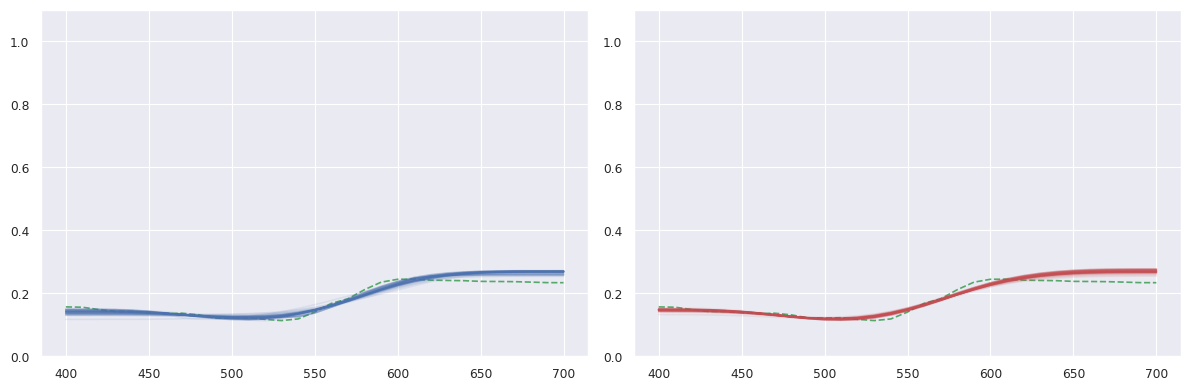

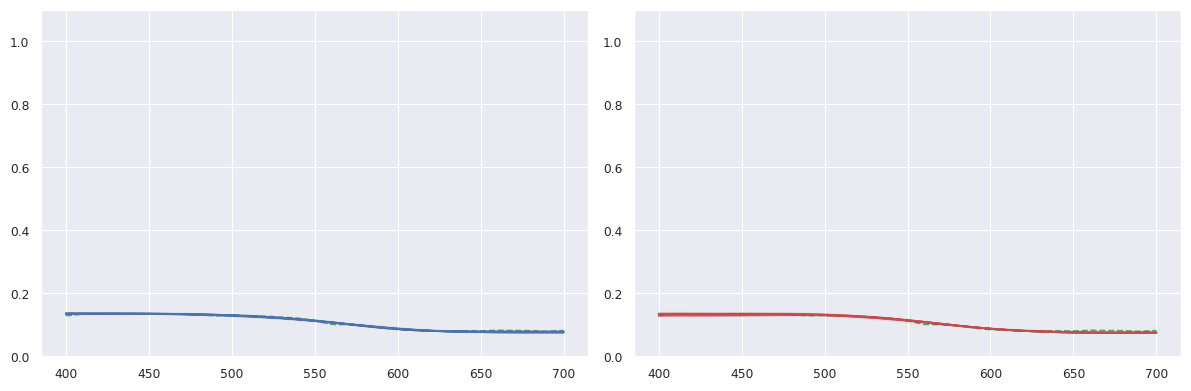

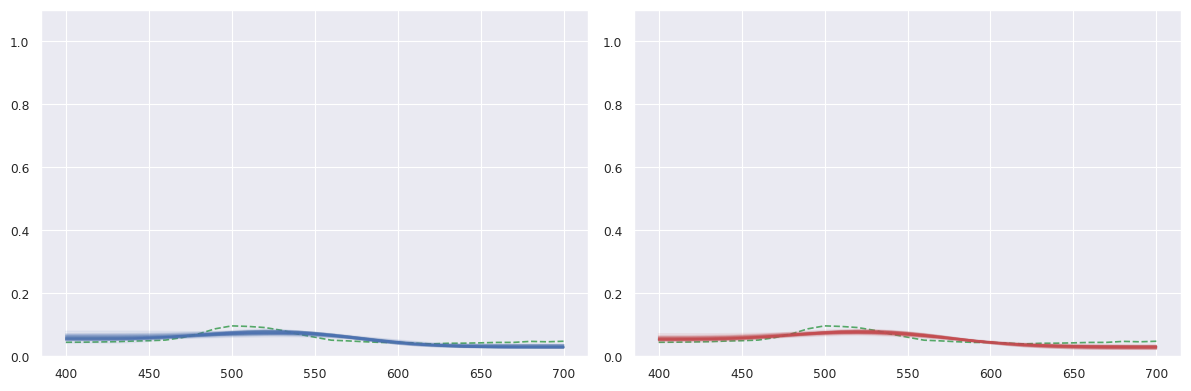

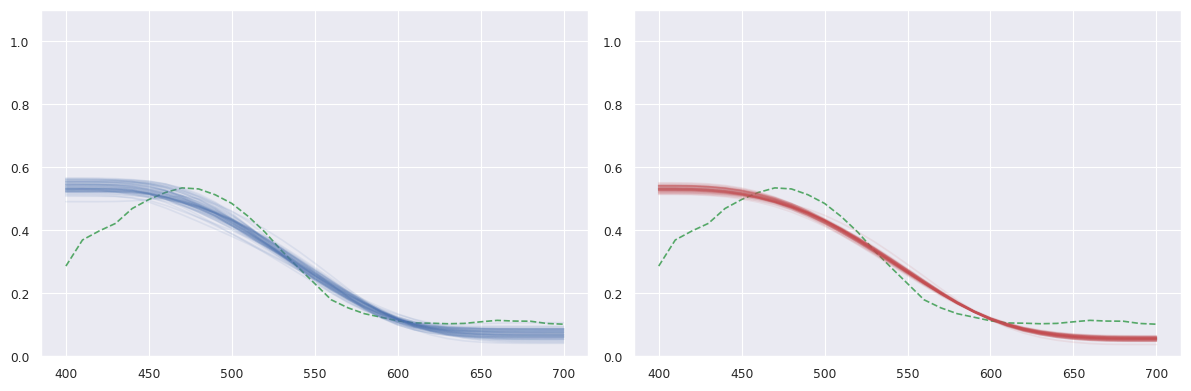

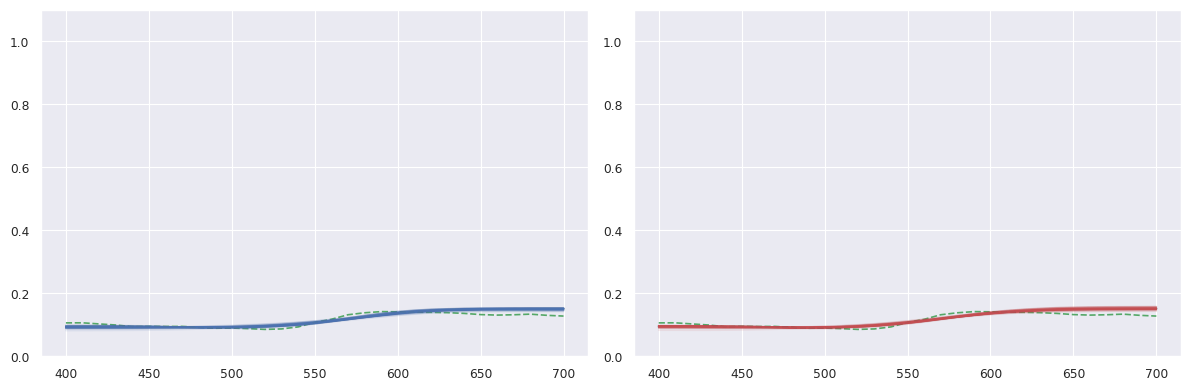

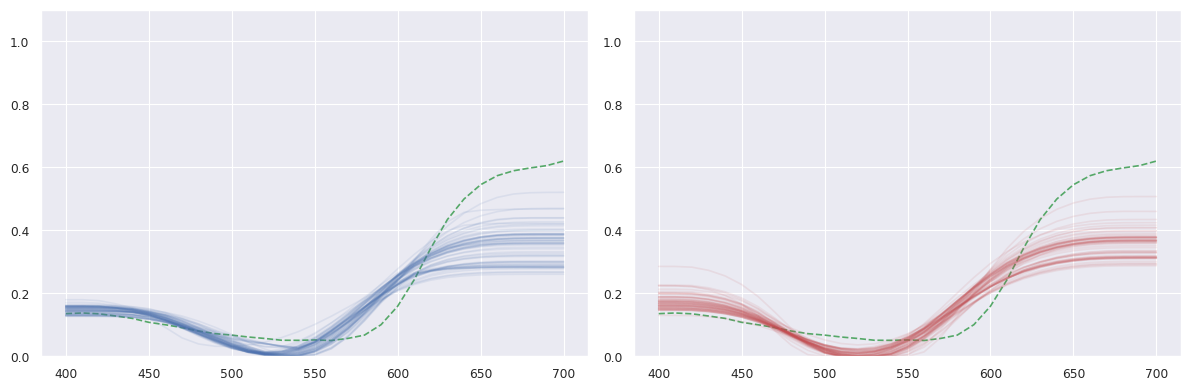

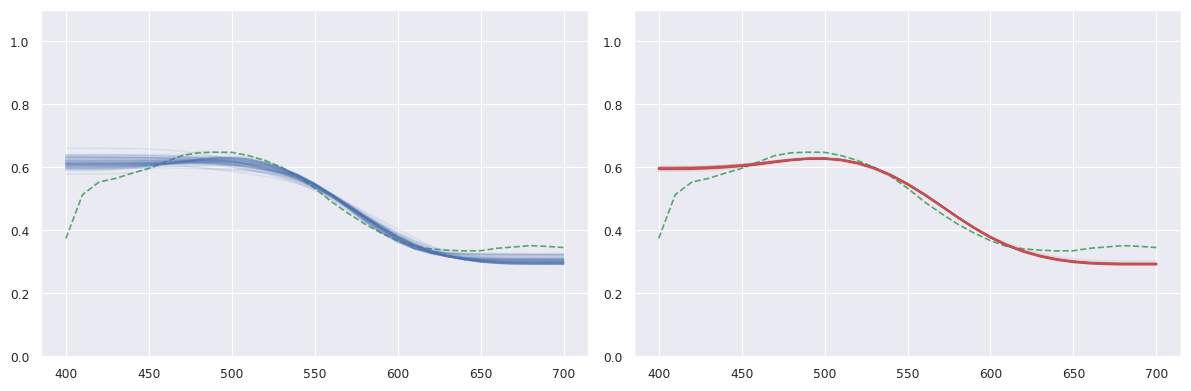

In [44]:
rows = num_samples # 12
cols = 2

sns.set_theme('paper')
wavelengths = np.arange(400, 710, 10)

for i in range(num_samples):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax_direct = axes[0]
    ax_direct.plot(wavelengths, original_list[i], 'g--', label='Изначальный')
    for rec_s in recovered_list[i]:
        ax_direct.plot(wavelengths, rec_s, 'b', alpha=0.1)
    ax_direct.set_ylim(0, 1.1)

    ax_d65 = axes[1]
    ax_d65.plot(wavelengths, original_list[i], 'g--', label='Изначальный')
    for rec_d65 in recovered_list_from_D65[i]:
        ax_d65.plot(wavelengths, rec_d65, 'r', alpha=0.1)
    ax_d65.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

In [41]:
def calculate_stability_metric(data):
    mu = np.mean(data, axis=1)
    norm_mu = np.linalg.norm(mu, axis=1)
    diffs = data - mu[:, np.newaxis, :]
    norm_diffs = np.linalg.norm(diffs, axis=2)
    errors = norm_diffs / norm_mu[:, np.newaxis]
    return np.mean(errors) * 100

error_direct = calculate_stability_metric(recovered_list)
error_d65 = calculate_stability_metric(recovered_list_from_D65)

print(f"Средняя ошибка стабильности при восстановлении напрямую: {error_direct:.2f}%")
print(f"Средняя ошибка стабильности при восстановлении через d65: {error_d65:.2f}%")

Средняя ошибка стабильности при восстановлении напрямую: 3.39%
Средняя ошибка стабильности при восстановлении через d65: 2.41%
